In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# import stsandard libraries

import pandas as pd
import numpy as np
from scipy.fft import fft
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Delta 0.5 - 4Hz, deep sleep and restorative process
# Theta 4 - 8 Hz, Light sleep, deep relaxation, and creative states, inward focus
# Alpha 8 - 13 Hz, Relaxed wakefulness, day dreaming, closed eyes, meditation
# Beta 13 - 30 Hz, Active thinking, concentration, alertness and problem solving
# Gamma  30 - 60 Hz, learning, problem solving and information processing

In [ ]:
time_segment_sets = [
    [[0.0000,10.0000],[11.0000,21.0000], [21.0000,31.0000], [32.0000,42.0000],[42.0000,52.0000],[53.0000,63.0000]],
    [[64.0000,74.0000],[75.0000,85.0000], [85.0000,95.0000], [96.0000,106.0000],[107.0000,117.0000],[117.0000,127.0000]],
    [[127.0000,138.0000],[139.0000,149.0000], [149.0000,159.0000], [160.0000,170.0000],[170.0000,180.0000],[181.0000,191.0000]],
    [[192.0000,202.0000],[203.0000,213.0000], [213.0000,223.0000], [224.0000,234.0000],[234.0000,244.0000],[245.0000,255.0000]],
    [[256.0000,266.0000],[267.0000,277.0000], [277.0000,287.0000], [288.0000,298.0000],[298.0000,308.0000],[309.0000,319.0000]],
    [[320.0000,330.0000],[331.0000,341.0000], [341.0000,351.0000], [352.0000,362.0000],[363.0000,373.0000],[374.0000,384.0000]]
    ]

In [ ]:
# utility function to load from a mind monitor data csv file and prepare a dataframe

# this function expects the input csv file will have following columns
#       'TimeStamp', 'RAW_TP9', 'RAW_AF7', 'RAW_AF8', 'RAW_TP10'
def load_df_from_file(csv_file, timestamp_deduplicate_callback):
    df = pd.read_csv(csv_file)
    df = df[df.iloc[:,:-1].isna().sum(axis=1) == 0].iloc[:,:-1]
    _ts = pd.to_datetime(df['TimeStamp']).astype('int64')
    df['TimeStamp'] = (_ts - _ts.iloc[0]) / 1000000000

    df = timestamp_deduplicate_callback(df)
    return df

In [ ]:
def extract_subtable_and_reformat(df, columns_to_analyze):
    df = df[columns_to_analyze]
    df.set_index('TimeStamp', inplace=True)
    return df

In [ ]:
# utility function to de-duplicate Timestamps by incrementally adding a fractional time
def increment_timestamps(df):
    # increment = pd.Timedelta(microseconds=1)
    increment = 0.0001
    prev_val = df['TimeStamp'].iloc[0]
    for i in range(1, len(df)):
        curr_val = df['TimeStamp'].iloc[i]
        while curr_val - prev_val <= increment:
            curr_val = curr_val + increment
            df['TimeStamp'].iloc[i] = curr_val
        prev_val = curr_val
    return df

# alternate options include doing group average as follows
#raw_signal_df = raw_signal_df.groupby('TimeStamp').mean()

In [ ]:
def analyse_intrinsic_changes_psd(df, psd_col_name, reference_time_slots):

    feature_list = df.columns.tolist()
    title_post = ' '.join(feature_list)
    # title_str = 'Power Spectral Density : (' + title_post + ')'
    # plt.figure(figsize=(10, 6))
    fig, axs = plt.subplots(len(reference_time_slots), 1, figsize=(10, 12))
    cnt = 0
    for ts in reference_time_slots:
        segment_df = df.loc[ts[0]:ts[1]]
        axs[cnt].plot(segment_df.index, segment_df[psd_col_name], label=psd_col_name)
        axs[cnt].set_xlabel('TimeStamp')
        axs[cnt].set_ylabel('Power Spectral Density (uV^2/Hz)')
        axs[cnt].set_title('Power Spectral Density')
        axs[cnt].legend()
        axs[cnt].grid(True)
        cnt +=1
    # plt.xticks(rotation=45)  # Rotate the x-axis labels for better readability
    plt.tight_layout()  # Adjust layout to prevent clipping of labels
    plt.show()


    return

In [ ]:
def plot_psd_segment(df, segment):
    segment_df = df.loc[segment[0]:segment[1]]
    feature_list = df.columns.tolist()
    title_post = ' '.join(feature_list)
    title_str = 'Power Spectral Density : (' + title_post + ')'
    plt.figure(figsize=(10, 6))
    for f in feature_list:
        plt.plot(segment_df.index, segment_df[f], label=f)
    plt.xlabel('TimeStamp')
    plt.ylabel('Power Spectral Density (uV^2/Hz)')
    plt.title(title_str)
    plt.legend()
    plt.xticks(rotation=45)  # Rotate the x-axis labels for better readability
    plt.tight_layout()  # Adjust layout to prevent clipping of labels
    plt.show()


In [ ]:
def get_anova_input_set_with_2var(df, psd_col_name, reference_time_slots_array):
    min = 0
    array_of_dfs = {}

    idx = 1

    segment_df = df.loc[0.0000:10.0000].copy()
    segment_df.insert(0, 'Subject', idx)
    segment_df.insert(0, 'Music', 0)
    segment_df.insert(0, 'ErrorInj', 0)

    # Initialize an empty list to store all segments
    all_segments = [segment_df]

    # Loop through each array of reference time slots
    for reference_time_slots in reference_time_slots_array:
        # Initialize an empty list to store the segments for the current set of time slots
        segments = []

        # Loop through each time slot within the current set
        for ts in reference_time_slots:
            segment_df = df.loc[ts[0]:ts[1]].copy()
            segment_df.insert(0, 'Subject', idx)
            segment_df.insert(0, 'Music', 1)
            segment_df.insert(0, 'ErrorInj', 0)
            segments.append(segment_df)

        # Update the 'ErrorInj' column in the last segment of the current set
        if segments:
            segments[-1]['ErrorInj'] = 1

        # Append all segments of the current set to the list of all segments
        all_segments.extend(segments)


    # Concatenate all segments into a single DataFrame
    concatenated_df = pd.concat(all_segments, ignore_index=True)
    return concatenated_df


In [ ]:
def run_anova_test2(df, psd_col_name):
    formula = f'{psd_col_name} ~ C(Music) * C(ErrorInj)'
    model = ols(formula, data=df).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    # aovrm = AnovaRM(df, depvar=dv, subject=psd_col_name
    # return anova_table

    return anova_table

In [ ]:
!ls ./drive/MyDrive/MindMonitorData

'Diya Harmony-3.csv'	 'Jesal Rhythm.csv'	 'Reva Melody.csv'	  'Srikala Harmony.csv'
'Diya Melody-2 (2).csv'  'Preeti Harmony-2.csv'  'Reva Rhythm.csv'	  'Srikala Melody.csv'
'Diya Rhythm 2.csv'	 'Preeti Melody-2.csv'	 'Sakshi Harmony -3.csv'  'Srikala Rhythm.csv'
'Jesal Harmony.csv'	  Preeti-Rhythm-4.csv	 'Sakshi Melody -3.csv'
'Jesal Melody.csv'	 'Reva Harmony.csv'	 'Sakshi Rhythm -3.csv'


In [ ]:
# input_file = "./drive/MyDrive/MindMonitorData/Participant1 Rhythm-4.csv"
# input_file = "./drive/MyDrive/MindMonitorData/Participant2 Rhythm 2.csv"
# input_file = "./drive/MyDrive/MindMonitorData/Participant3 Rhythm.csv"
# input_file = "./drive/MyDrive/MindMonitorData/Participant1 Harmony-2.csv"
# input_file = "./drive/MyDrive/MindMonitorData/Participant2 Harmony-3.csv"
# input_file = "./drive/MyDrive/MindMonitorData/Participant3 Harmony.csv"
# input_file = "./drive/MyDrive/MindMonitorData/Participant1 Melody-2.csv"
# input_file = "./drive/MyDrive/MindMonitorData/Participant2 Melody-2 (2).csv"
# input_file = "./drive/MyDrive/MindMonitorData/Participant3 Melody.csv"
# input_file = "./drive/MyDrive/MindMonitorData/Participant4 Rhythm.csv"
# input_file = "./drive/MyDrive/MindMonitorData/Participant4 Harmony.csv"
# input_file = "./drive/MyDrive/MindMonitorData/Participant4 Melody.csv"
# input_file = "./drive/MyDrive/MindMonitorData/Participant5 Rhythm.csv"
# input_file = "./drive/MyDrive/MindMonitorData/Participant5 Harmony.csv"
# input_file = "./drive/MyDrive/MindMonitorData/Participant5 Melody.csv"

# input_file = "./drive/MyDrive/MindMonitorData/Participant6 Rhythm -3.csv"
# input_file = "./drive/MyDrive/MindMonitorData/Participant6 Harmony -3.csv"
input_file = "./drive/MyDrive/MindMonitorData/Participant6 Melody -3.csv"

raw_signal_df = load_df_from_file(input_file, increment_timestamps)

Streaming output truncated to the last 5000 lines.

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['TimeStamp'].iloc[i] = curr_val
<ipython-input-6-7d6d43642bf4>:10: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignm

In [ ]:
# raw_signal_df
# data_columns = ['TimeStamp', 'RAW_TP9', 'RAW_AF7', 'RAW_AF8', 'RAW_TP10']
# beta_columns = ['TimeStamp', 'Beta_TP9', 'Beta_TP10', 'Beta_AF7', 'Beta_AF8']
# gamma_columns = ['TimeStamp', 'Gamma_TP9', 'Gamma_TP10', 'Gamma_AF7', 'Gamma_AF8']

# all_columns = ['TimeStamp', 'Beta_TP9', 'Beta_TP10', 'Beta_AF7', 'Beta_AF8', 'Gamma_TP9', 'Gamma_TP10', 'Gamma_AF7', 'Gamma_AF8',
#               'Delta_TP9', 'Delta_TP10', 'Delta_AF7', 'Delta_AF8', 'Theta_TP9', 'Theta_TP10', 'Theta_AF7', 'Theta_AF8',
#               'Alpha_TP9', 'Alpha_TP10', 'Alpha_AF7', 'Alpha_AF8'
#              ]


data_columns = ['TimeStamp',
                'Delta_TP9', 'Theta_TP9', 'Alpha_TP9', 'Beta_TP9', 'Gamma_TP9',
                'Delta_TP10', 'Theta_TP10', 'Alpha_TP10', 'Beta_TP10', 'Gamma_TP10',
                'Delta_AF7', 'Theta_AF7', 'Alpha_AF7', 'Beta_AF7', 'Gamma_AF7',
                'Delta_AF8', 'Theta_AF8', 'Alpha_AF8', 'Beta_AF8', 'Gamma_AF8'
               ]
test_df = extract_subtable_and_reformat(raw_signal_df, data_columns)


In [ ]:
processed_df = get_anova_input_set_with_2var(test_df, 'Beta_TP9', time_segment_sets)
processed_df

,ErrorInj,Music,Subject,Delta_TP9,Theta_TP9,Alpha_TP9,Beta_TP9,Gamma_TP9,Delta_TP10,Theta_TP10,...,Delta_AF7,Theta_AF7,Alpha_AF7,Beta_AF7,Gamma_AF7,Delta_AF8,Theta_AF8,Alpha_AF8,Beta_AF8,Gamma_AF8
0,0,0,1,0.195985,0.484216,0.651340,0.451207,0.035964,0.262690,0.579017,...,0.208175,0.082910,-0.049749,0.042212,-0.609175,0.053049,-0.090761,0.079043,-0.071880,-0.532559
1,0,0,1,0.195985,0.484216,0.651340,0.451207,0.035964,0.262690,0.579017,...,0.208175,0.082910,-0.049749,0.042212,-0.609175,0.053049,-0.090761,0.079043,-0.071880,-0.532559
2,0,0,1,0.195985,0.484216,0.651340,0.451207,0.035964,0.262690,0.579017,...,0.208175,0.082910,-0.049749,0.042212,-0.609175,0.053049,-0.090761,0.079043,-0.071880,-0.532559
3,0,0,1,0.195985,0.484216,0.651340,0.451207,0.035964,0.262690,0.579017,...,0.208175,0.082910,-0.049749,0.042212,-0.609175,0.053049,-0.090761,0.079043,-0.071880,-0.532559
4,0,0,1,0.195985,0.484216,0.651340,0.451207,0.035964,0.262690,0.579017,...,0.208175,0.082910,-0.049749,0.042212,-0.609175,0.053049,-0.090761,0.079043,-0.071880,-0.532559
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92748,1,1,1,0.426320,0.490232,0.642139,0.260888,-0.333120,0.507559,0.266489,...,0.153223,0.050413,0.186542,-0.168316,-0.569153,-0.047578,-0.276415,-0.135736,-0.020267,-0.512378
92749,1,1,1,0.426320,0.490232,0.642139,0.260888,-0.333120,0.507559,0.266489,...,0.153223,0.050413,0.186542,-0.168316,-0.569153,-0.047578,-0.276415,-0.135736,-0.020267,-0.512378
92750,1,1,1,0.426320,0.490232,0.642139,0.260888,-0.333120,0.507559,0.266489,...,0.153223,0.050413,0.186542,-0.168316,-0.569153,-0.047578,-0.276415,-0.135736,-0.020267,-0.512378
92751,1,1,1,0.426320,0.490232,0.642139,0.260888,-0.333120,0.507559,0.266489,...,0.153223,0.050413,0.186542,-0.168316,-0.569153,-0.047578,-0.276415,-0.135736,-0.020267,-0.512378


In [ ]:
def do_anova(df, reference_time_slots):
    results_list = []
    for psd_signal_name in df.columns:
      trial =0
      for exp in reference_time_slots:
        processed_df = get_anova_input_set_with_2var(df, psd_signal_name, [exp])
        anv = run_anova_test2(processed_df, psd_signal_name)
        anv.insert(0, 'wave', psd_signal_name)

        result_dict = {
          'trial': trial,
          'wave': psd_signal_name,
          'PR(>F) C(Music)': anv.loc['C(Music)', 'PR(>F)'],
          'PR(>F) C(ErrorInj)': anv.loc['C(ErrorInj)', 'PR(>F)'],
          'PR(>F) C(Music):C(ErrorInj)': anv.loc['C(Music):C(ErrorInj)', 'PR(>F)']
        }

        trial += 1

        results_list.append(result_dict)

    # results_list.append(result_dict)

    results_df = pd.DataFrame(results_list)  # Convert the results list to a dataframe
    # results_list.append(anv.iloc[0].to_frame().T)  # Append the ANOVA result to the results dataframe
    # results_df = pd.concat(results_list)
    return results_df

In [ ]:
psd_signal_name='Beta_TP9'
processed_df = get_anova_input_set_with_2var(test_df, psd_signal_name, [time_segment_sets[0]])
run_anova_test2(processed_df, psd_signal_name)

,sum_sq,df,F,PR(>F)
C(Music),3.210487e+00,1.0,3.279821e+02,1.136782e-72
C(ErrorInj),4.935395e-12,1.0,5.041981e-10,9.999821e-01
C(Music):C(ErrorInj),1.351919e+01,1.0,1.381115e+03,1.588369e-291
Residual,1.794642e+02,18334.0,NaN,NaN


In [ ]:
results_df = do_anova(test_df, time_segment_sets)

In [ ]:
results_df

,trial,wave,PR(>F) C(Music),PR(>F) C(ErrorInj),PR(>F) C(Music):C(ErrorInj)
0,0,Delta_TP9,5.895143e-01,0.999997,0.000000e+00
1,1,Delta_TP9,4.773007e-47,1.000000,6.005607e-06
2,2,Delta_TP9,2.280525e-57,0.999997,0.000000e+00
3,3,Delta_TP9,6.705286e-01,1.000000,0.000000e+00
4,4,Delta_TP9,2.919171e-31,1.000000,5.131764e-203
...,...,...,...,...,...
115,1,Gamma_AF8,9.027859e-136,1.000000,1.247912e-246
116,2,Gamma_AF8,6.871886e-114,0.999993,1.368366e-11
117,3,Gamma_AF8,2.455932e-57,1.000000,1.034805e-142
118,4,Gamma_AF8,1.646940e-219,1.000000,0.000000e+00


In [ ]:
grouped = results_df.groupby('wave')
column = 'PR(>F) C(Music):C(ErrorInj)'
threshold = 0.05
percentages = grouped.apply(lambda x: (x[column] < threshold).mean() * 100)
percentage_df = percentages.reset_index(name=f'Percentage of times {column} < {threshold}')

# Display the results
print(percentage_df)
# Convert to markdown table format
#markdown_table = percentage_df['Percentage of times PR(>F) C(Music):C(ErrorInj) < 0.05'].to_markdown(index=False)
#print(markdown_table)

          wave  Percentage of times PR(>F) C(Music):C(ErrorInj) < 0.05
0    Alpha_AF7                                         100.000000     
1    Alpha_AF8                                         100.000000     
2   Alpha_TP10                                         100.000000     
3    Alpha_TP9                                          83.333333     
4     Beta_AF7                                          66.666667     
5     Beta_AF8                                         100.000000     
6    Beta_TP10                                         100.000000     
7     Beta_TP9                                         100.000000     
8    Delta_AF7                                         100.000000     
9    Delta_AF8                                         100.000000     
10  Delta_TP10                                          83.333333     
11   Delta_TP9                                         100.000000     
12   Gamma_AF7                                          83.333333     
13   G

<ipython-input-33-61143b749b1b>:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  percentages = grouped.apply(lambda x: (x[column] < threshold).mean() * 100)


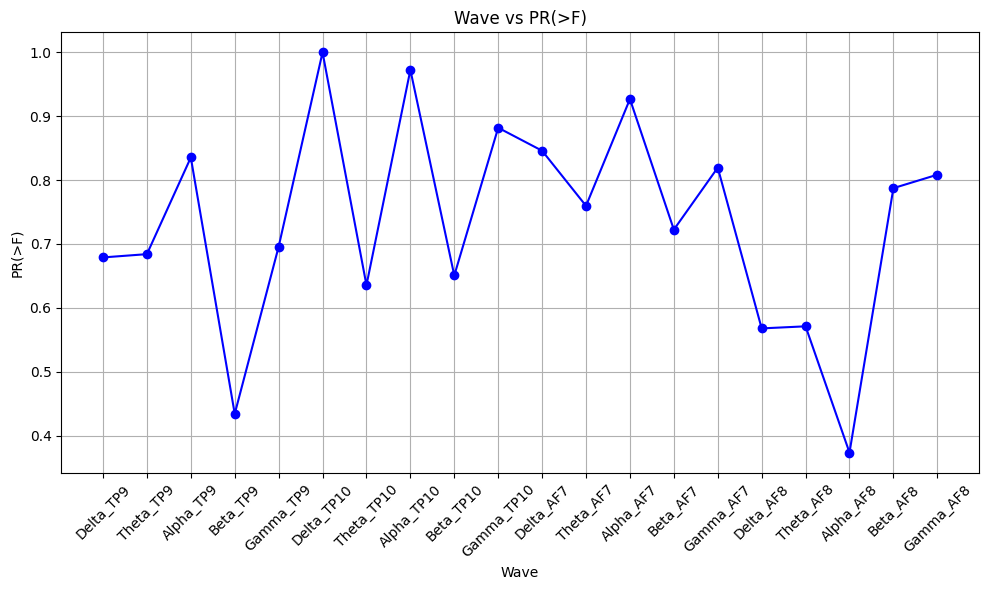

In [ ]:

#results_df_cleaned = results_df[results_df['wave'] != 'Alpha_TP9']
#results_df_cleaned = results_df_cleaned[results_df['wave'] != 'Alpha_TP10']
#results_df_cleaned = results_df_cleaned[results_df['wave'] != 'Delta_TP9']
# results_df_cleaned = results_df_cleaned[results_df['wave'] != 'Beta_TP9']
import pandas as pd
import matplotlib.pyplot as plt


# Plotting
plt.figure(figsize=(10, 6))
plt.plot(results_df['wave'], results_df['PR(>F) C(Music):C(ErrorInj)'], marker='o', linestyle='-', color='b')
plt.xlabel('Wave')
plt.ylabel('PR(>F)')
plt.title('Wave vs PR(>F)')
plt.grid(True)
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to prevent clipping of labels
plt.show()

In [ ]:
results_df

In [ ]:
psd_signal_name='Alpha_TP9'
processed_df = get_anova_input_set_with_1var(test_df, psd_signal_name, time_segment_sets)
run_anova_test2(processed_df, psd_signal_name)

In [ ]:
psd_signal_name='Alpha_TP10'
processed_df = get_anova_input_set_with_1var(test_df, psd_signal_name, time_segment_sets)
run_anova_test2(processed_df, psd_signal_name)

In [ ]:
psd_signal_name='Beta_TP9'
processed_df = get_anova_input_set_with_1var(test_df, psd_signal_name, time_segment_sets)
run_anova_test2(processed_df, psd_signal_name)

In [ ]:
psd_signal_name='Beta_TP10'
processed_df = get_anova_input_set_with_1var(test_df, psd_signal_name, time_segment_sets)
run_anova_test2(processed_df, psd_signal_name)

In [ ]:
psd_signal_name='Gamma_TP9'
processed_df = get_anova_input_set_with_1var(test_df, psd_signal_name, time_segment_sets)
run_anova_test2(processed_df, psd_signal_name)

In [ ]:
run_anova_test(arr_of_dfs[1], arr_of_dfs[2])

In [ ]:
run_anova_test(arr_of_dfs[1], arr_of_dfs[3])